# Analisis Statistika dan Probabilitas Lengkap (Semester 3)
### Studi Kasus: Dataset Risiko Serangan Jantung (`dataset/dataset_serangan_jantung.csv`)
**Program Studi:** Ilmu Komputer / Teknik Informatika / Sistem Informasi / Sains Data  
**Mata Kuliah:** Statistika dan Probabilitas (Semester 3)

---

## Ringkasan Silabus yang Diterapkan
Notebook ini dirancang sebagai panduan komprehensif dan aplikatif yang mengintegrasikan seluruh pokok bahasan perkuliahan **Statistika dan Probabilitas Semester 3**:

1. **Modul 1: Persiapan Lingkungan & Pemuatan Data**
2. **Modul 2: Distribusi Frekuensi Berkelompok (Aturan Sturges) & Kurva Ogive**
3. **Modul 3: Statistika Deskriptif Komprehensif (Pemusatan, Letak, Dispersi, MAD, SE, Skewness, Kurtosis)**
4. **Modul 4: Evaluasi Asumsi Normalitas (Visualisasi Q-Q Plot & Uji Formal)**
5. **Modul 5: Teori Probabilitas Dasar, Peluang Bersyarat, Relative Risk, & Teorema Bayes**
6. **Modul 6: Distribusi Probabilitas Teoretis (Binomial, Poisson, Normal, & Transformasi Skor Z)**
7. **Modul 7: Teorema Limit Pusat (CLT) & Estimasi Interval (Confidence Interval 95%)**
8. **Modul 8: Pengujian Hipotesis Parametrik (Two-Sample t-Test, Two-Sample Z-Test Proporsi, One-Way ANOVA F-Test)**
9. **Modul 9: Pengujian Hipotesis Non-Parametrik (Chi-Square Goodness-of-Fit, Chi-Square Independensi, Mann-Whitney U Test)**
10. **Modul 10: Analisis Kovarians, Korelasi (Pearson & Spearman), dan Regresi Linier Sederhana**
11. **Modul 11: Ringkasan Eksekutif & Kesimpulan Akhir**


---
## Modul 1: Persiapan Lingkungan & Pemuatan Data

Pustaka yang digunakan mencakup:
- `numpy` dan `pandas` untuk manipulasi struktur data dan perhitungan numerik.
- `scipy.stats` untuk fungsi probabilitas, uji statistik parametrik dan non-parametrik.
- `matplotlib.pyplot` dan `seaborn` untuk penyajian grafik statistik standar akademis.
- `sklearn.linear_model` untuk pemodelan regresi linier.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

# Jalur berkas dataset
dataset_candidates = [
    'dataset/dataset_serangan_jantung.csv',
    '../dataset/dataset_serangan_jantung.csv',
    '/home/akbar/workspace/study/semester_3/statistic/tugas_uts/statistic_data/dataset/dataset_serangan_jantung.csv'
]

dataset_path = None
for path in dataset_candidates:
    if os.path.exists(path):
        dataset_path = path
        break

if dataset_path is None:
    raise FileNotFoundError("Berkas dataset_serangan_jantung.csv tidak ditemukan.")

df = pd.read_csv(dataset_path)
print(f"Dataset berhasil dimuat dari: {dataset_path}")
print(f"Dimensi Data: {df.shape[0]:,} baris dan {df.shape[1]} kolom")
df.head(5)


Dataset berhasil dimuat dari: ../dataset/dataset_serangan_jantung.csv
Dimensi Data: 79,583 baris dan 16 kolom


,patient_id,gender,age,body_mass_index,smoker,systolic_blood_pressure,hypertension_treated,family_history_of_cardiovascular_disease,atrial_fibrillation,chronic_kidney_disease,rheumatoid_arthritis,diabetes,chronic_obstructive_pulmonary_disorder,forced_expiratory_volume_1,time_to_event_or_censoring,heart_attack
0,PT00030699,F,31,25.9,0,112.0,1,0,0,0,0,0,0,90.969833,10,0
1,PT00018951,F,72,28.6,0,125.0,1,0,0,1,0,0,0,NaN,10,0
2,PT00027657,F,28,NaN,0,102.0,0,0,0,0,0,0,0,98.376954,10,0
3,PT00099298,F,63,NaN,0,NaN,0,0,0,0,0,0,0,NaN,10,0
4,PT00050564,F,35,NaN,0,111.0,1,0,0,0,0,0,0,NaN,10,0


### 1.1 Identifikasi Tipe Data dan Nilai Hilang (*Missing Values*)
Dalam analisis statistik inferensial, penanganan data hilang perlu diperhitungkan agar estimasi parameter tidak bias.


In [2]:
missing_df = pd.DataFrame({
    'Tipe Data': df.dtypes,
    'Jumlah Hilang': df.isnull().sum(),
    'Persentase Hilang (%)': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_df[missing_df['Jumlah Hilang'] > 0]


,Tipe Data,Jumlah Hilang,Persentase Hilang (%)
body_mass_index,float64,23832,29.95
systolic_blood_pressure,float64,7815,9.82
forced_expiratory_volume_1,float64,55253,69.43


---
## Modul 2: Distribusi Frekuensi Berkelompok (Aturan Sturges) & Kurva Ogive

Dalam statistika deskriptif, menyajikan data mentah kontinu dalam bentuk **Tabel Distribusi Frekuensi Berkelompok** mempermudah pengenalan pola sebaran data.

### Formulasi:
1. **Jumlah Kelas ($k$) menurut Aturan Sturges:**
   $$k = 1 + 3{,}322 \log_{10}(n)$$
2. **Jangkauan (*Range*):**
   $$R = x_{\max} - x_{\min}$$
3. **Panjang Interval Kelas ($c$):**
   $$c = \left\lceil \frac{R}{k} \right\rceil$$
4. **Batas Kelas & Tepi Kelas:**
   - Batas Bawah ($BB$) dan Batas Atas ($BA$).
   - Tepi Bawah ($TB = BB - 0{,}5$) dan Tepi Atas ($TA = BA + 0{,}5$).
5. **Frekuensi Kumulatif & Kurva Ogive:**
   - **Ogive Positif:** Berdasarkan frekuensi kumulatif "kurang dari" ($F_{\le}$).
   - **Ogive Negatif:** Berdasarkan frekuensi kumulatif "lebih dari" ($F_{\ge}$).


In [3]:
# Penerapan Aturan Sturges pada Variabel Usia (Age)
series_age = df['age'].dropna()
n_obs = len(series_age)
min_age = series_age.min()
max_age = series_age.max()
range_age = max_age - min_age

k_sturges = int(np.ceil(1 + 3.322 * np.log10(n_obs)))
panjang_kelas = int(np.ceil(range_age / k_sturges))

# Pembuatan Interval Kelas
bins = [min_age + i * panjang_kelas for i in range(k_sturges + 1)]
labels = [f"{bins[i]} - {bins[i+1]-1}" for i in range(k_sturges)]

age_grouped = pd.cut(series_age, bins=bins, right=False, labels=labels)
freq_table = pd.DataFrame(age_grouped.value_counts(sort=False)).reset_index()
freq_table.columns = ['Interval Kelas', 'Frekuensi (f)']

# Menghitung Titik Tengah (xi), Tepi Bawah (TB), Tepi Atas (TA), Frekuensi Relatif, & Kumulatif
tb_list, ta_list, xi_list = [], [], []
for i in range(k_sturges):
    bb = bins[i]
    ba = bins[i+1] - 1
    tb_list.append(bb - 0.5)
    ta_list.append(ba + 0.5)
    xi_list.append((bb + ba) / 2)

freq_table['Titik Tengah (xi)'] = xi_list
freq_table['Tepi Bawah (TB)'] = tb_list
freq_table['Tepi Atas (TA)'] = ta_list
freq_table['Frekuensi Relatif (%)'] = (freq_table['Frekuensi (f)'] / n_obs * 100).round(2)
freq_table['Frek Kumulatif (<=)'] = freq_table['Frekuensi (f)'].cumsum()
freq_table['Frek Kumulatif (>=)'] = n_obs - freq_table['Frek Kumulatif (<=)'] + freq_table['Frekuensi (f)']

print(f"Parameter Sturges: n={n_obs:,}, Range={range_age}, k={k_sturges}, Panjang Kelas={panjang_kelas}")
freq_table


Parameter Sturges: n=79,583, Range=61, k=18, Panjang Kelas=4


,Interval Kelas,Frekuensi (f),Titik Tengah (xi),Tepi Bawah (TB),Tepi Atas (TA),Frekuensi Relatif (%),Frek Kumulatif (<=),Frek Kumulatif (>=)
0,18 - 21,4447,19.5,17.5,21.5,5.59,4447,79583
1,22 - 25,5704,23.5,21.5,25.5,7.17,10151,75136
2,26 - 29,5547,27.5,25.5,29.5,6.97,15698,69432
3,30 - 33,5951,31.5,29.5,33.5,7.48,21649,63885
4,34 - 37,5761,35.5,33.5,37.5,7.24,27410,57934
5,38 - 41,5631,39.5,37.5,41.5,7.08,33041,52173
6,42 - 45,5329,43.5,41.5,45.5,6.70,38370,46542
7,46 - 49,5205,47.5,45.5,49.5,6.54,43575,41213
8,50 - 53,5753,51.5,49.5,53.5,7.23,49328,36008
9,54 - 57,5884,55.5,53.5,57.5,7.39,55212,30255


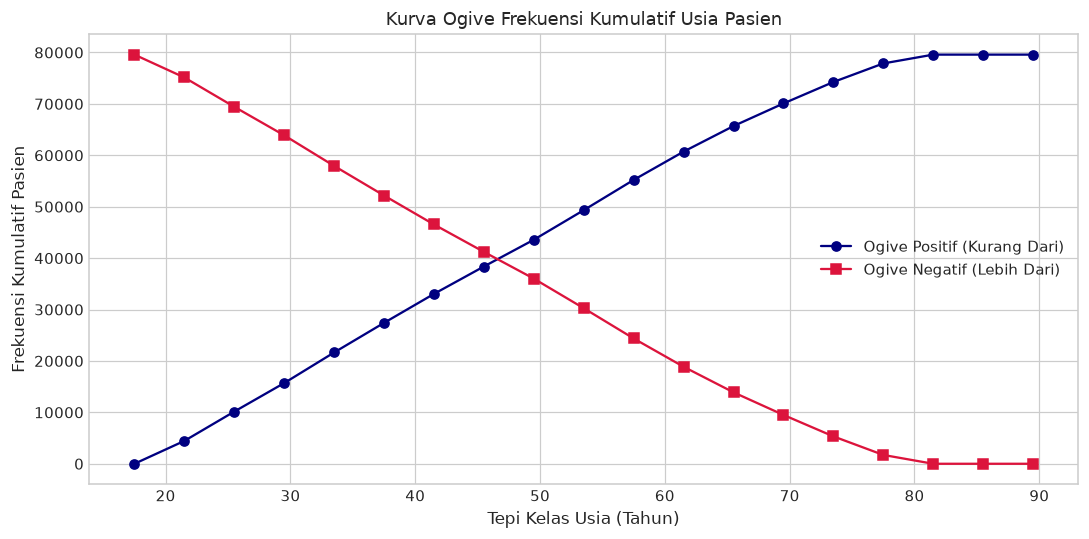

In [4]:
# Visualisasi Kurva Ogive Positif dan Ogive Negatif
fig, ax = plt.subplots(figsize=(10, 5))

# Data titik tepi atas untuk ogive positif
ogive_pos_x = [freq_table['Tepi Bawah (TB)'].iloc[0]] + list(freq_table['Tepi Atas (TA)'])
ogive_pos_y = [0] + list(freq_table['Frek Kumulatif (<=)'])

# Data titik tepi bawah untuk ogive negatif
ogive_neg_x = list(freq_table['Tepi Bawah (TB)']) + [freq_table['Tepi Atas (TA)'].iloc[-1]]
ogive_neg_y = list(freq_table['Frek Kumulatif (>=)']) + [0]

ax.plot(ogive_pos_x, ogive_pos_y, marker='o', color='navy', label='Ogive Positif (Kurang Dari)')
ax.plot(ogive_neg_x, ogive_neg_y, marker='s', color='crimson', label='Ogive Negatif (Lebih Dari)')

ax.set_title("Kurva Ogive Frekuensi Kumulatif Usia Pasien")
ax.set_xlabel("Tepi Kelas Usia (Tahun)")
ax.set_ylabel("Frekuensi Kumulatif Pasien")
ax.legend()
plt.tight_layout()
plt.show()


---
## Modul 3: Statistika Deskriptif Komprehensif

Statistika deskriptif mencakup pengukuran seluruh aspek distribusi:
1. **Pemusatan:** Mean ($\bar{x}$), Median ($Me$), Modus ($Mo$).
2. **Letak:** Kuartil ($Q_1, Q_2, Q_3$), $IQR = Q_3 - Q_1$, Batas Outlier Tukey ($Q_1 - 1{,}5 IQR$ dan $Q_3 + 1{,}5 IQR$).
3. **Penyebaran / Dispersi:**
   - Jangkauan ($Range$)
   - Varians Sampel ($s^2 = \frac{\sum (x_i-\bar{x})^2}{n-1}$)
   - Standar Deviasi ($s = \sqrt{s^2}$)
   - Standar Galat Rata-rata ($SE_{\bar{x}} = \frac{s}{\sqrt{n}}$)
   - Deviasi Rata-rata / Mean Absolute Deviation ($MAD = \frac{1}{n} \sum |x_i - \bar{x}|$)
   - Koefisien Variasi ($CV = \frac{s}{\bar{x}} \times 100\%$)
4. **Bentuk Distribusi:**
   - Skewness (Kemiringan, formula Fisher-Pearson).
   - Kurtosis (Keruncingan relatif terhadap normal = 0).


In [5]:
numeric_vars = ['age', 'systolic_blood_pressure', 'body_mass_index']
stats_records = []

for var in numeric_vars:
    series = df[var].dropna()
    n = len(series)
    mean_val = series.mean()
    median_val = series.median()
    mode_val = series.mode().iloc[0]
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    range_val = series.max() - series.min()
    var_sample = series.var(ddof=1)
    std_sample = series.std(ddof=1)
    se_val = std_sample / np.sqrt(n)
    mad_val = np.mean(np.abs(series - mean_val))
    cv_val = (std_sample / mean_val) * 100
    skew_val = stats.skew(series)
    kurt_val = stats.kurtosis(series)
    
    # Deteksi Outlier
    outliers = ((series < (q1 - 1.5 * iqr)) | (series > (q3 + 1.5 * iqr))).sum()
    
    stats_records.append({
        'Variabel': var,
        'N Valid': n,
        'Mean': round(mean_val, 2),
        'Median': round(median_val, 2),
        'Modus': round(mode_val, 2),
        'Q1': round(q1, 2),
        'Q3': round(q3, 2),
        'IQR': round(iqr, 2),
        'Range': round(range_val, 2),
        'Varians (s^2)': round(var_sample, 2),
        'Std Dev (s)': round(std_sample, 2),
        'SE Mean': round(se_val, 3),
        'MAD': round(mad_val, 2),
        'CV (%)': round(cv_val, 2),
        'Skewness': round(skew_val, 3),
        'Kurtosis': round(kurt_val, 3),
        'Jumlah Outlier': outliers
    })

pd.DataFrame(stats_records).T


,0,1,2
Variabel,age,systolic_blood_pressure,body_mass_index
N Valid,79583,71768,55751
Mean,46.94,129.88,26.98
Median,47.0,129.0,27.1
Modus,22.0,127.0,27.9
Q1,32.0,118.0,24.1
Q3,61.0,141.0,30.0
IQR,29.0,23.0,5.9
Range,61.0,158.0,40.1
Varians (s^2),287.8,312.75,20.29


---
## Modul 4: Evaluasi Asumsi Normalitas (Visualisasi Q-Q Plot & Uji Formal)

Sebelum menjalankan pengujian parametrik (seperti uji $t$ dan ANOVA), asumsi normalitas harus diperiksa:
1. **Metode Grafis (Q-Q Plot / Quantile-Quantile Plot):**
   Membandingkan kuantil data empiris terhadap kuantil teoretis distribusi normal baku. Jika titik-titik data berada di sepanjang garis diagonal $45^\circ$, data mengikuti distribusi normal.
2. **Uji Statistik Formal (D'Agostino-Pearson Omnibus Test):**
   - $H_0$: Data berasal dari populasi berdistribusi normal.
   - $H_1$: Data tidak berdistribusi normal.


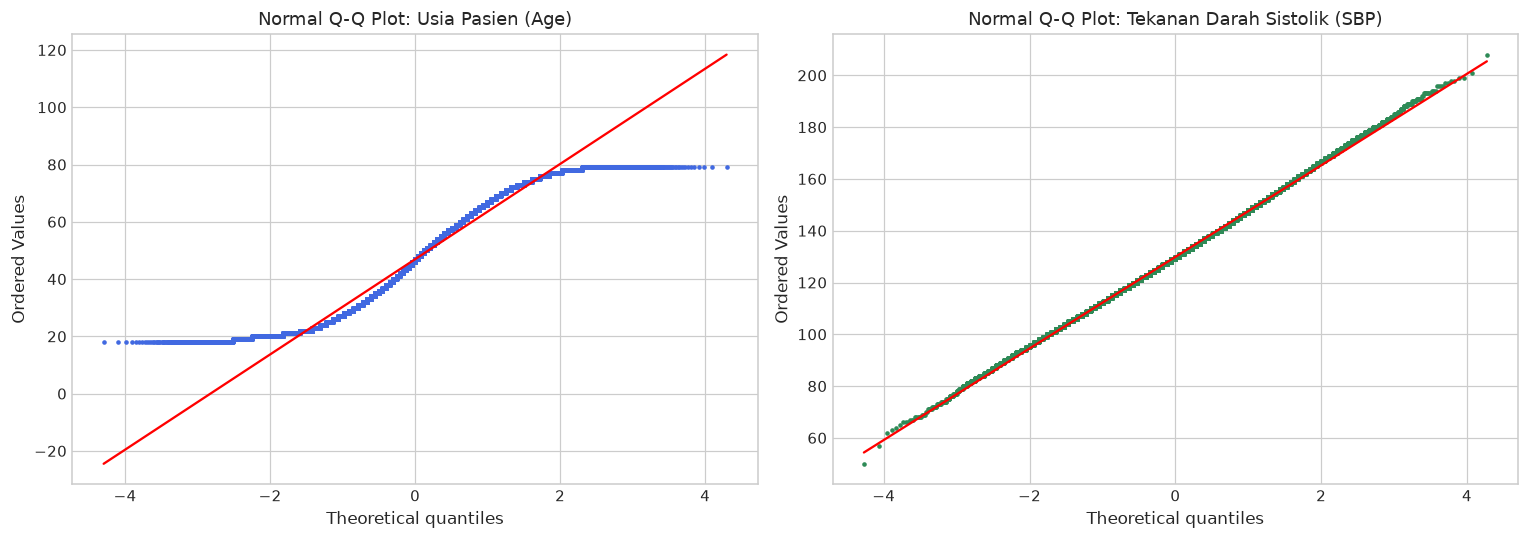

--- Hasil Uji Normalitas Formal (D'Agostino-Pearson) ---
Usia (Age)                 : Statistik=37546.5411, p-value=0.0000e+00
Tekanan Darah Sistolik     : Statistik=133.7547, p-value=9.0267e-30
Catatan: Pada sampel data berukuran sangat besar (N > 50.000), uji formal sensitif terhadap deviasi minor, sehingga Q-Q plot dan Central Limit Theorem (CLT) menjadi rujukan utama.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Q-Q Plot Usia
stats.probplot(df['age'], dist="norm", plot=axes[0])
axes[0].set_title("Normal Q-Q Plot: Usia Pasien (Age)")
axes[0].get_lines()[0].set_color('royalblue')
axes[0].get_lines()[0].set_markersize(2)
axes[0].get_lines()[1].set_color('red')

# Q-Q Plot Tekanan Darah Sistolik
sbp_valid = df['systolic_blood_pressure'].dropna()
stats.probplot(sbp_valid, dist="norm", plot=axes[1])
axes[1].set_title("Normal Q-Q Plot: Tekanan Darah Sistolik (SBP)")
axes[1].get_lines()[0].set_color('seagreen')
axes[1].get_lines()[0].set_markersize(2)
axes[1].get_lines()[1].set_color('red')

plt.tight_layout()
plt.show()

# Uji Formal D'Agostino-Pearson Omnibus Normalitas
stat_age, p_age = stats.normaltest(df['age'])
stat_sbp, p_sbp = stats.normaltest(sbp_valid)

print("--- Hasil Uji Normalitas Formal (D'Agostino-Pearson) ---")
print(f"Usia (Age)                 : Statistik={stat_age:.4f}, p-value={p_age:.4e}")
print(f"Tekanan Darah Sistolik     : Statistik={stat_sbp:.4f}, p-value={p_sbp:.4e}")
print("Catatan: Pada sampel data berukuran sangat besar (N > 50.000), uji formal sensitif terhadap deviasi minor, sehingga Q-Q plot dan Central Limit Theorem (CLT) menjadi rujukan utama.")


---
## Modul 5: Teori Probabilitas Dasar, Peluang Bersyarat, Relative Risk, & Teorema Bayes

### Formulasi:
1. **Peluang Marginal / Prior:**
   $$P(A) = \frac{n(A)}{N}$$
2. **Peluang Bersyarat (Conditional Probability):**
   $$P(A \mid B) = \frac{P(A \cap B)}{P(B)}$$
3. **Risiko Relatif (*Relative Risk* / RR):**
   $$RR = \frac{P(\text{Serangan} \mid \text{Faktor Risiko} = 1)}{P(\text{Serangan} \mid \text{Faktor Risiko} = 0)}$$
4. **Teorema Bayes:**
   $$P(B \mid A) = \frac{P(A \mid B) \cdot P(B)}{P(A)}$$


In [7]:
# 1. Peluang Marginal
p_ha = (df['heart_attack'] == 1).mean()
p_diab = (df['diabetes'] == 1).mean()
p_smoke = (df['smoker'] == 1).mean()
p_fam = (df['family_history_of_cardiovascular_disease'] == 1).mean()

print("--- 1. Peluang Marginal (Prior) ---")
print(f"P(Heart Attack = 1)          : {p_ha:.4f} ({p_ha*100:.2f}%)")
print(f"P(Diabetes = 1)              : {p_diab:.4f} ({p_diab*100:.2f}%)")
print(f"P(Smoker = 1)                : {p_smoke:.4f} ({p_smoke*100:.2f}%)")
print(f"P(Family History CVD = 1)    : {p_fam:.4f} ({p_fam*100:.2f}%)")

# 2. Peluang Bersyarat & Relative Risk
p_ha_given_diab = df[df['diabetes'] == 1]['heart_attack'].mean()
p_ha_given_no_diab = df[df['diabetes'] == 0]['heart_attack'].mean()
rr_diab = p_ha_given_diab / p_ha_given_no_diab

print("\n--- 2. Peluang Bersyarat & Relative Risk ---")
print(f"P(Heart Attack | Diabetes = 1) : {p_ha_given_diab:.4f} ({p_ha_given_diab*100:.2f}%)")
print(f"P(Heart Attack | Diabetes = 0) : {p_ha_given_no_diab:.4f} ({p_ha_given_no_diab*100:.2f}%)")
print(f"Relative Risk (RR) Diabetes    : {rr_diab:.2f}x lipat risiko terkena serangan jantung")

# 3. Teorema Bayes: P(Diabetes | Heart Attack)
p_diab_given_ha_bayes = (p_ha_given_diab * p_diab) / p_ha
p_diab_given_ha_empiris = df[df['heart_attack'] == 1]['diabetes'].mean()

print("\n--- 3. Teorema Bayes (Posterior Probability) ---")
print(f"P(Diabetes | Heart Attack) Teorema Bayes : {p_diab_given_ha_bayes:.4f}")
print(f"P(Diabetes | Heart Attack) Empiris Data  : {p_diab_given_ha_empiris:.4f}")


--- 1. Peluang Marginal (Prior) ---
P(Heart Attack = 1)          : 0.0664 (6.64%)
P(Diabetes = 1)              : 0.0950 (9.50%)
P(Smoker = 1)                : 0.0853 (8.53%)
P(Family History CVD = 1)    : 0.1664 (16.64%)

--- 2. Peluang Bersyarat & Relative Risk ---
P(Heart Attack | Diabetes = 1) : 0.1673 (16.73%)
P(Heart Attack | Diabetes = 0) : 0.0559 (5.59%)
Relative Risk (RR) Diabetes    : 3.00x lipat risiko terkena serangan jantung

--- 3. Teorema Bayes (Posterior Probability) ---
P(Diabetes | Heart Attack) Teorema Bayes : 0.2392
P(Diabetes | Heart Attack) Empiris Data  : 0.2392


---
## Modul 6: Distribusi Probabilitas Teoretis (Binomial, Poisson, Normal, & Z-Score)

### 6.1 Distribusi Diskrit: Binomial & Poisson
- **Binomial:** Memodelkan jumlah penderita serangan jantung ($X$) dari $n=30$ pasien terpilih secara acak:
  $$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$
- **Poisson:** Memodelkan kedatangan kasus dengan rata-rata $\lambda = n \cdot p$:
  $$P(X = k) = \frac{\lambda^k e^{-\lambda}}{k!}$$


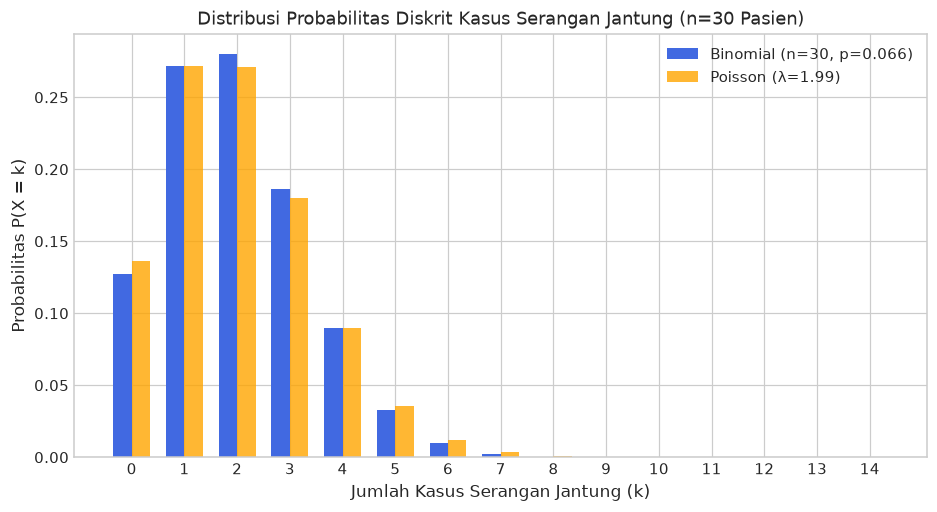

Probabilitas klinik mendeteksi LEBIH DARI 2 kasus serangan jantung dalam 30 pasien:
P(X > 2) = 1 - P(X <= 2) = 0.3214 (32.14%)


In [8]:
n_sample = 30
p_val = p_ha
k_arr = np.arange(0, 15)

pmf_binom = stats.binom.pmf(k_arr, n_sample, p_val)
lambda_p = n_sample * p_val
pmf_pois = stats.poisson.pmf(k_arr, lambda_p)

fig, ax = plt.subplots(figsize=(10, 5))
w = 0.35
ax.bar(k_arr - w/2, pmf_binom, width=w, color='royalblue', label=f'Binomial (n={n_sample}, p={p_val:.3f})')
ax.bar(k_arr + w/2, pmf_pois, width=w, color='orange', alpha=0.8, label=f'Poisson (λ={lambda_p:.2f})')
ax.set_title("Distribusi Probabilitas Diskrit Kasus Serangan Jantung (n=30 Pasien)")
ax.set_xlabel("Jumlah Kasus Serangan Jantung (k)")
ax.set_ylabel("Probabilitas P(X = k)")
ax.set_xticks(k_arr)
ax.legend()
plt.show()

# Probabilitas Kumulatif Binomial
p_lebih_dari_2 = 1 - stats.binom.cdf(2, n_sample, p_val)
print(f"Probabilitas klinik mendeteksi LEBIH DARI 2 kasus serangan jantung dalam 30 pasien:")
print(f"P(X > 2) = 1 - P(X <= 2) = {p_lebih_dari_2:.4f} ({p_lebih_dari_2*100:.2f}%)")


### 6.2 Distribusi Kontinu: Normal & Transformasi Z-Score
Variabel Tekanan Darah Sistolik ($X$) dimodelkan dengan kurva normal $\mathcal{N}(\mu, \sigma^2)$:
$$Z = \frac{X - \mu}{\sigma}$$
Menghitung probabilitas pasien mengalami Hipertensi Derajat 1 ($X \ge 140$ mmHg):


Parameter Model: Mean (μ) = 129.88 mmHg, Std Dev (σ) = 17.68 mmHg
Skor Z untuk X = 140 mmHg       : 0.572
P(SBP >= 140) Teoretis Normal   : 0.2837 (28.37%)
P(SBP >= 140) Aktual di Dataset : 0.2858 (28.58%)


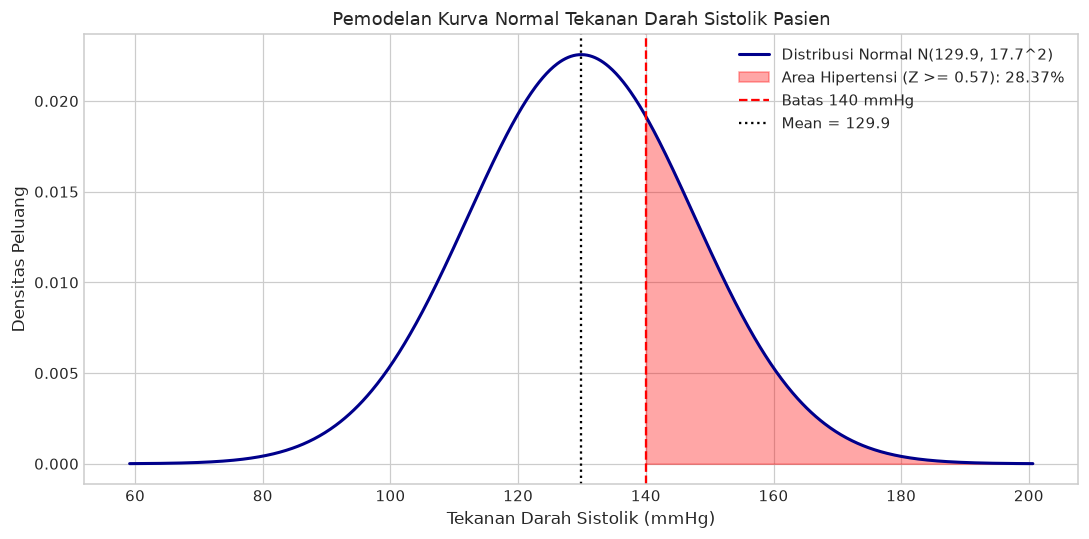

In [9]:
mu_sbp = sbp_valid.mean()
sigma_sbp = sbp_valid.std()
x_hipertensi = 140

z_calc = (x_hipertensi - mu_sbp) / sigma_sbp
p_teori_normal = stats.norm.sf(z_calc)
p_aktual_hipertensi = (sbp_valid >= x_hipertensi).mean()

print(f"Parameter Model: Mean (μ) = {mu_sbp:.2f} mmHg, Std Dev (σ) = {sigma_sbp:.2f} mmHg")
print(f"Skor Z untuk X = 140 mmHg       : {z_calc:.3f}")
print(f"P(SBP >= 140) Teoretis Normal   : {p_teori_normal:.4f} ({p_teori_normal*100:.2f}%)")
print(f"P(SBP >= 140) Aktual di Dataset : {p_aktual_hipertensi:.4f} ({p_aktual_hipertensi*100:.2f}%)")

# Visualisasi Kurva Normal Baku dan Luas Probabilitas
x_grid = np.linspace(mu_sbp - 4*sigma_sbp, mu_sbp + 4*sigma_sbp, 1000)
pdf_grid = stats.norm.pdf(x_grid, mu_sbp, sigma_sbp)

plt.figure(figsize=(10, 5))
plt.plot(x_grid, pdf_grid, color='darkblue', lw=2, label=f'Distribusi Normal N({mu_sbp:.1f}, {sigma_sbp:.1f}^2)')
plt.fill_between(x_grid, pdf_grid, where=(x_grid >= x_hipertensi), color='red', alpha=0.35, 
                 label=f'Area Hipertensi (Z >= {z_calc:.2f}): {p_teori_normal*100:.2f}%')
plt.axvline(x_hipertensi, color='red', linestyle='--', label='Batas 140 mmHg')
plt.axvline(mu_sbp, color='black', linestyle=':', label=f'Mean = {mu_sbp:.1f}')
plt.title("Pemodelan Kurva Normal Tekanan Darah Sistolik Pasien")
plt.xlabel("Tekanan Darah Sistolik (mmHg)")
plt.ylabel("Densitas Peluang")
plt.legend()
plt.tight_layout()
plt.show()


---
## Modul 7: Teorema Limit Pusat (CLT) & Estimasi Interval (Confidence Interval 95%)

### 7.1 Teorema Limit Pusat (Central Limit Theorem)
Distribusi rata-rata sampel ($\bar{X}$) akan berdistribusi normal dengan rata-rata $\mu$ dan galat baku $SE = \frac{\sigma}{\sqrt{n}}$ ketika ukuran sampel $n$ membesar, meskipun populasi aslinya tidak berdistribusi normal sempurna.


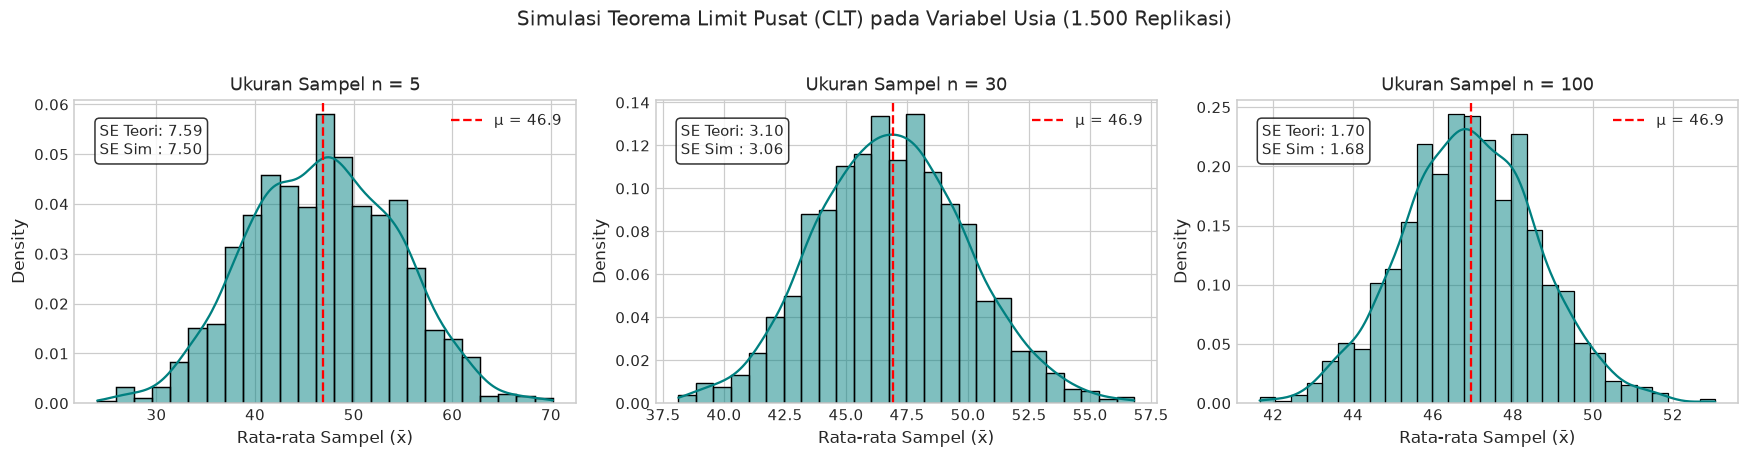

In [10]:
np.random.seed(42)
pop_age = df['age'].values
b_reps = 1500
n_sizes = [5, 30, 100]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, n_i in enumerate(n_sizes):
    sample_means = [np.mean(np.random.choice(pop_age, size=n_i, replace=True)) for _ in range(b_reps)]
    sns.histplot(sample_means, kde=True, ax=axes[i], color='teal', stat='density')
    axes[i].set_title(f"Ukuran Sampel n = {n_i}")
    axes[i].set_xlabel("Rata-rata Sampel (x̄)")
    axes[i].axvline(np.mean(pop_age), color='red', linestyle='--', label=f"μ = {np.mean(pop_age):.1f}")
    
    se_teori = pop_age.std() / np.sqrt(n_i)
    se_emp = np.std(sample_means)
    axes[i].text(0.05, 0.82, f"SE Teori: {se_teori:.2f}\nSE Sim : {se_emp:.2f}", 
                 transform=axes[i].transAxes, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    axes[i].legend()

plt.suptitle("Simulasi Teorema Limit Pusat (CLT) pada Variabel Usia (1.500 Replikasi)", fontsize=13, y=1.03)
plt.tight_layout()
plt.show()


### 7.2 Estimasi Parameter: Selang Kepercayaan (Confidence Interval 95%)
- **Untuk Rata-rata ($\mu$):** $\bar{x} \pm t_{\alpha/2, n-1} \cdot \frac{s}{\sqrt{n}}$
- **Untuk Proporsi ($p$):** $\hat{p} \pm Z_{\alpha/2} \cdot \sqrt{\frac{\hat{p}(1-\hat{p})}{n}}$


In [11]:
# Menarik sampel acak berukuran n = 250 untuk simulasi inferensi statistik
np.random.seed(77)
sample_250 = df.sample(n=250)

# 1. CI 95% untuk Rata-rata Usia
n_samp = len(sample_250)
x_bar = sample_250['age'].mean()
s_samp = sample_250['age'].std(ddof=1)
se_x = s_samp / np.sqrt(n_samp)
ci_age = stats.t.interval(0.95, df=n_samp - 1, loc=x_bar, scale=se_x)

# 2. CI 95% untuk Proporsi Kasus Serangan Jantung
p_hat = sample_250['heart_attack'].mean()
se_prop = np.sqrt(p_hat * (1 - p_hat) / n_samp)
z_crit = stats.norm.ppf(0.975)
ci_prop = (p_hat - z_crit * se_prop, p_hat + z_crit * se_prop)

print("--- Hasil Estimasi Parameter Sampel (n = 250) ---")
print(f"Rata-rata Sampel (x̄)          : {x_bar:.2f} tahun")
print(f"95% CI Rata-rata Usia         : [{ci_age[0]:.2f}, {ci_age[1]:.2f}] tahun")
print(f"Nilai Rata-rata Populasi (μ)   : {df['age'].mean():.2f} tahun")

print(f"\nProporsi Kasus Sampel (p̂)     : {p_hat:.4f} ({p_hat*100:.2f}%)")
print(f"95% CI Proporsi Kasus         : [{ci_prop[0]:.4f}, {ci_prop[1]:.4f}] ({ci_prop[0]*100:.2f}% s.d. {ci_prop[1]*100:.2f}%)")
print(f"Nilai Proporsi Populasi (p)    : {p_ha:.4f} ({p_ha*100:.2f}%)")


--- Hasil Estimasi Parameter Sampel (n = 250) ---
Rata-rata Sampel (x̄)          : 46.19 tahun
95% CI Rata-rata Usia         : [44.12, 48.26] tahun
Nilai Rata-rata Populasi (μ)   : 46.94 tahun

Proporsi Kasus Sampel (p̂)     : 0.0720 (7.20%)
95% CI Proporsi Kasus         : [0.0400, 0.1040] (4.00% s.d. 10.40%)
Nilai Proporsi Populasi (p)    : 0.0664 (6.64%)


---
## Modul 8: Pengujian Hipotesis Parametrik (Uji Hipotesis Rata-rata & Proporsi)

Pengujian hipotesis parametrik menguji parameter populasi berdasarkan distribusi probabilitas teoritis.

---

### 8.1 Uji Beda Rata-rata Dua Sampel Independen (Two-Sample Independent $t$-Test)
**Kasus:** Menguji apakah rata-rata usia pasien penderita serangan jantung berbeda signifikan dari non-penderita.
- $H_0: \mu_1 = \mu_2$ (Rata-rata usia sama)
- $H_1: \mu_1 > \mu_2$ (Rata-rata usia penderita serangan jantung lebih tinggi)


In [12]:
ha_group = df[df['heart_attack'] == 1]['age']
non_ha_group = df[df['heart_attack'] == 0]['age']

# Uji Homogenitas Varians (Levene's Test)
lev_stat, lev_pval = stats.levene(ha_group, non_ha_group)
var_equal = lev_pval > 0.05
print(f"Uji Levene Varians: Stat={lev_stat:.4f}, p-value={lev_pval:.4e} -> Gunakan Welch t-test")

# Welch's Two-Sample t-test
t_res = stats.ttest_ind(ha_group, non_ha_group, equal_var=False, alternative='greater')
print(f"Rata-rata Usia Serangan Jantung   : {ha_group.mean():.2f} tahun (n={len(ha_group):,})")
print(f"Rata-rata Usia Non-Serangan Jantung: {non_ha_group.mean():.2f} tahun (n={len(non_ha_group):,})")
print(f"Nilai t-hitung                     : {t_res.statistic:.4f}")
print(f"Derajat Kebebasan (df)             : {t_res.df:.2f}")
print(f"p-value                            : {t_res.pvalue:.4e}")
print("Keputusan: Tolak H0 (p < 0.001). Pasien serangan jantung terbukti signifikan memiliki usia lebih tinggi.")


Uji Levene Varians: Stat=1727.1374, p-value=0.0000e+00 -> Gunakan Welch t-test
Rata-rata Usia Serangan Jantung   : 64.58 tahun (n=5,288)
Rata-rata Usia Non-Serangan Jantung: 45.68 tahun (n=74,295)
Nilai t-hitung                     : 108.8483
Derajat Kebebasan (df)             : 6859.41
p-value                            : 0.0000e+00
Keputusan: Tolak H0 (p < 0.001). Pasien serangan jantung terbukti signifikan memiliki usia lebih tinggi.


### 8.2 Uji Beda Dua Proporsi (Two-Sample $Z$-Test for Proportions)
**Kasus:** Menguji apakah proporsi kejadian serangan jantung pada pasien laki-laki ($p_1$) berbeda secara signifikan dengan perempuan ($p_2$).
- $H_0: p_1 = p_2$
- $H_1: p_1 \neq p_2$

Statistik Uji:
$$Z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\bar{p}(1-\bar{p})\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}, \quad \bar{p} = \frac{x_1 + x_2}{n_1 + n_2}$$


In [13]:
# Data Laki-laki (M) vs Perempuan (F)
df_male = df[df['gender'] == 'M']
df_female = df[df['gender'] == 'F']

n_m = len(df_male)
n_f = len(df_female)
x_m = (df_male['heart_attack'] == 1).sum()
x_f = (df_female['heart_attack'] == 1).sum()

p_m = x_m / n_m
p_f = x_f / n_f
p_pool = (x_m + x_f) / (n_m + n_f)

se_diff = np.sqrt(p_pool * (1 - p_pool) * (1/n_m + 1/n_f))
z_stat = (p_m - p_f) / se_diff
p_val_z = 2 * (1 - stats.norm.cdf(abs(z_stat)))

print("--- Hasil Uji Beda Dua Proporsi (Two-Sample Z-Test) ---")
print(f"Proporsi Serangan Jantung Laki-laki (p̂1) : {p_m:.4f} ({p_m*100:.2f}%) [n={n_m:,}]")
print(f"Proporsi Serangan Jantung Perempuan (p̂2) : {p_f:.4f} ({p_f*100:.2f}%) [n={n_f:,}]")
print(f"Nilai Z-hitung                          : {z_stat:.4f}")
print(f"p-value (Two-Tailed)                    : {p_val_z:.4e}")

if p_val_z < 0.05:
    print("Keputusan: Tolak H0 (p < 0.05).")
    print("Kesimpulan: Terdapat perbedaan proporsi serangan jantung yang sangat signifikan antara laki-laki dan perempuan.")


--- Hasil Uji Beda Dua Proporsi (Two-Sample Z-Test) ---
Proporsi Serangan Jantung Laki-laki (p̂1) : 0.0797 (7.97%) [n=40,159]
Proporsi Serangan Jantung Perempuan (p̂2) : 0.0529 (5.29%) [n=39,424]
Nilai Z-hitung                          : 15.1892
p-value (Two-Tailed)                    : 0.0000e+00
Keputusan: Tolak H0 (p < 0.05).
Kesimpulan: Terdapat perbedaan proporsi serangan jantung yang sangat signifikan antara laki-laki dan perempuan.


### 8.3 Analisis Varians Satu Arah (One-Way ANOVA / $F$-Test)
**Kasus:** Menguji apakah terdapat perbedaan rata-rata Tekanan Darah Sistolik antar 3 kelompok usia pasien:
1. Dewasa Muda (usia $\le 35$ tahun)
2. Dewasa Paruh Baya ($36 - 55$ tahun)
3. Lansia ($> 55$ tahun)

- $H_0: \mu_1 = \mu_2 = \mu_3$
- $H_1:$ Minimal ada satu pasang kelompok dengan rata-rata berbeda.


--- Hasil Analisis Varians Satu Arah (One-Way ANOVA) ---
Mean SBP Dewasa Muda       : 122.55 mmHg (n=22,119)
Mean SBP Dewasa Paruh Baya : 129.40 mmHg (n=24,956)
Mean SBP Lansia            : 136.95 mmHg (n=24,693)
Nilai F-hitung             : 4353.3749
p-value                    : 0.0000e+00
Keputusan: Tolak H0 (p < 0.05).
Kesimpulan: Rata-rata tekanan darah sistolik berbeda secara signifikan antar ketiga kelompok usia.


/tmp/ipykernel_5834/2793534103.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_anova, x='kategori_usia', y='systolic_blood_pressure', palette='Set2')


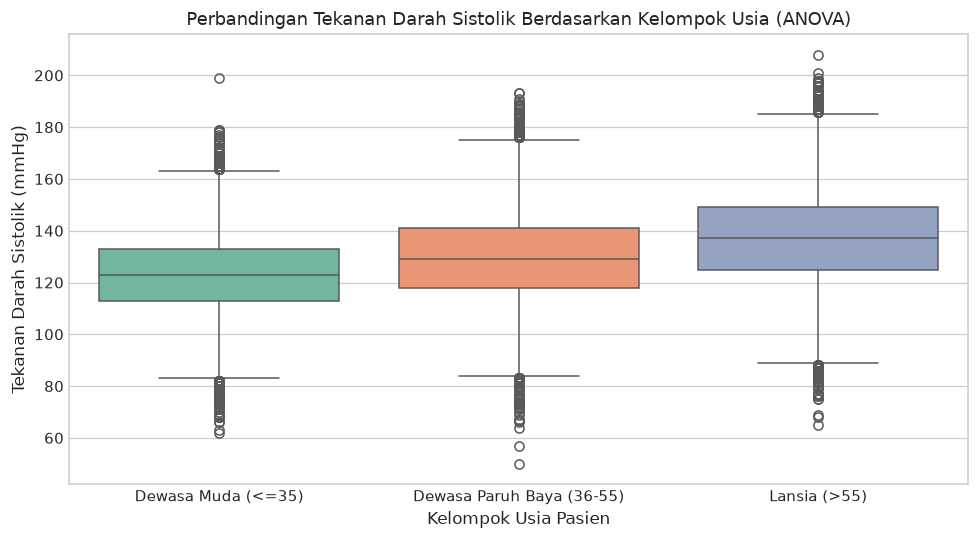

In [14]:
# Menyiapkan data kelompok usia
df_anova = df.dropna(subset=['systolic_blood_pressure']).copy()
df_anova['kategori_usia'] = pd.cut(
    df_anova['age'], 
    bins=[0, 35, 55, 120], 
    labels=['Dewasa Muda (<=35)', 'Dewasa Paruh Baya (36-55)', 'Lansia (>55)']
)

g1 = df_anova[df_anova['kategori_usia'] == 'Dewasa Muda (<=35)']['systolic_blood_pressure']
g2 = df_anova[df_anova['kategori_usia'] == 'Dewasa Paruh Baya (36-55)']['systolic_blood_pressure']
g3 = df_anova[df_anova['kategori_usia'] == 'Lansia (>55)']['systolic_blood_pressure']

f_stat, p_val_f = stats.f_oneway(g1, g2, g3)

print("--- Hasil Analisis Varians Satu Arah (One-Way ANOVA) ---")
print(f"Mean SBP Dewasa Muda       : {g1.mean():.2f} mmHg (n={len(g1):,})")
print(f"Mean SBP Dewasa Paruh Baya : {g2.mean():.2f} mmHg (n={len(g2):,})")
print(f"Mean SBP Lansia            : {g3.mean():.2f} mmHg (n={len(g3):,})")
print(f"Nilai F-hitung             : {f_stat:.4f}")
print(f"p-value                    : {p_val_f:.4e}")

if p_val_f < 0.05:
    print("Keputusan: Tolak H0 (p < 0.05).")
    print("Kesimpulan: Rata-rata tekanan darah sistolik berbeda secara signifikan antar ketiga kelompok usia.")

# Visualisasi Boxplot ANOVA
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_anova, x='kategori_usia', y='systolic_blood_pressure', palette='Set2')
plt.title("Perbandingan Tekanan Darah Sistolik Berdasarkan Kelompok Usia (ANOVA)")
plt.xlabel("Kelompok Usia Pasien")
plt.ylabel("Tekanan Darah Sistolik (mmHg)")
plt.tight_layout()
plt.show()


---
## Modul 9: Pengujian Hipotesis Non-Parametrik

Pengujian non-parametrik digunakan untuk data kategorikal atau data kontinu yang tidak memenuhi asumsi normalitas.

---

### 9.1 Uji Kesesuaian Chi-Square (Chi-Square Goodness-of-Fit Test)
**Kasus:** Menguji apakah distribusi jenis kelamin (Laki-laki vs Perempuan) pada dataset seimbang sesuai proporsi harapan 50% : 50% ($1:1$).
- $H_0: P(\text{Laki-laki}) = 0{,}50$ dan $P(\text{Perempuan}) = 0{,}50$
- $H_1:$ Proporsi aktual tidak mengikuti rasio 50:50


In [15]:
gender_counts = df['gender'].value_counts()
chi_gof, p_gof = stats.chisquare(gender_counts)

print("--- Hasil Uji Chi-Square Goodness-of-Fit (Rasio Gender) ---")
print(f"Frekuensi Observasi: Laki-laki={gender_counts['M']:,}, Perempuan={gender_counts['F']:,}")
print(f"Frekuensi Harapan  : Laki-laki={len(df)/2:,.1f}, Perempuan={len(df)/2:,.1f}")
print(f"Nilai χ² hitung    : {chi_gof:.4f}")
print(f"p-value            : {p_gof:.4f}")

if p_gof < 0.05:
    print("Keputusan: Tolak H0 pada alpha 0.05. Terdapat perbedaan signifikan proporsi gender dari rasio seimbang 50:50.")


--- Hasil Uji Chi-Square Goodness-of-Fit (Rasio Gender) ---
Frekuensi Observasi: Laki-laki=40,159, Perempuan=39,424
Frekuensi Harapan  : Laki-laki=39,791.5, Perempuan=39,791.5
Nilai χ² hitung    : 6.7882
p-value            : 0.0092
Keputusan: Tolak H0 pada alpha 0.05. Terdapat perbedaan signifikan proporsi gender dari rasio seimbang 50:50.


### 9.2 Uji Independensi Chi-Square (Chi-Square Test of Independence)
**Kasus:** Menguji independensi antara penyakit diabetes dan kejadian serangan jantung.
- $H_0:$ Diabetes dan Serangan Jantung saling bebas (independen).
- $H_1:$ Terdapat keterkaitan (dependensi) antara diabetes dan serangan jantung.


In [16]:
crosstab_diab = pd.crosstab(
    df['diabetes'].map({0: 'Non-Diabetes', 1: 'Diabetes'}),
    df['heart_attack'].map({0: 'Bukan Kasus', 1: 'Kasus Serangan'}),
    margins=True, margins_name='Total'
)
display(crosstab_diab)

chi2_val, p_chi2, dof_val, exp_matrix = stats.chi2_contingency(pd.crosstab(df['diabetes'], df['heart_attack']))
print(f"Nilai Chi-Square (χ²) Hitung : {chi2_val:.4f}")
print(f"Derajat Kebebasan (df)       : {dof_val}")
print(f"p-value                      : {p_chi2:.4e}")
print("Kesimpulan: Tolak H0. Terdapat hubungan dependensi yang sangat nyata antara diabetes dan serangan jantung.")


heart_attack,Bukan Kasus,Kasus Serangan,Total
diabetes,,,
Diabetes,6296,1265,7561
Non-Diabetes,67999,4023,72022
Total,74295,5288,79583


Nilai Chi-Square (χ²) Hitung : 1368.3223
Derajat Kebebasan (df)       : 1
p-value                      : 1.6074e-299
Kesimpulan: Tolak H0. Terdapat hubungan dependensi yang sangat nyata antara diabetes dan serangan jantung.


### 9.3 Uji Mann-Whitney $U$ (Uji Non-Parametrik Dua Sampel Independen)
Sebagai komparasi non-parametrik terhadap uji $t$, Uji Mann-Whitney $U$ membandingkan distribusi peringkat usia pasien serangan jantung vs non-serangan jantung.


In [17]:
u_stat, p_mann = stats.mannwhitneyu(ha_group, non_ha_group, alternative='greater')
print("--- Hasil Uji Non-Parametrik Mann-Whitney U ---")
print(f"Statistik U : {u_stat:,.1f}")
print(f"p-value     : {p_mann:.4e}")
print("Kesimpulan: Hasil uji Mann-Whitney U sejalan dengan uji t, menolak H0 (p < 0.001).")


--- Hasil Uji Non-Parametrik Mann-Whitney U ---
Statistik U : 320,010,942.5
p-value     : 0.0000e+00
Kesimpulan: Hasil uji Mann-Whitney U sejalan dengan uji t, menolak H0 (p < 0.001).


---
## Modul 10: Analisis Kovarians, Korelasi, dan Regresi Linier Sederhana

### Formulasi:
1. **Kovarians Sampel:**
   $$\operatorname{Cov}(X, Y) = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}{n - 1}$$
2. **Koefisien Korelasi Pearson ($r$):**
   $$r = \frac{\operatorname{Cov}(X, Y)}{s_X \cdot s_Y}$$
3. **Regresi Linier Sederhana (OLS):**
   $$Y = \beta_0 + \beta_1 X + \epsilon$$
   $$\beta_1 = \frac{\operatorname{Cov}(X, Y)}{s_X^2}, \quad \beta_0 = \bar{y} - \beta_1 \bar{x}$$


--- 1. Kovarians dan Korelasi ---
Kovarians Sampel Cov(Usia, SBP) : 104.4534
Korelasi Pearson (r)            : 0.3480 (p-value: 0.0000e+00)
Korelasi Spearman (ρ)           : 0.3452 (p-value: 0.0000e+00)

--- 2. Persamaan Garis Regresi Linier OLS ---
Persamaan: SBP = 112.8610 + 0.3625 * Usia
Intercept (β0) : 112.8610 mmHg
Slope (β1)     : 0.3625 mmHg per tahun usia
Koefisien Determinasi (R²) : 0.1211 (12.11%)
RMSE           : 16.5796 mmHg


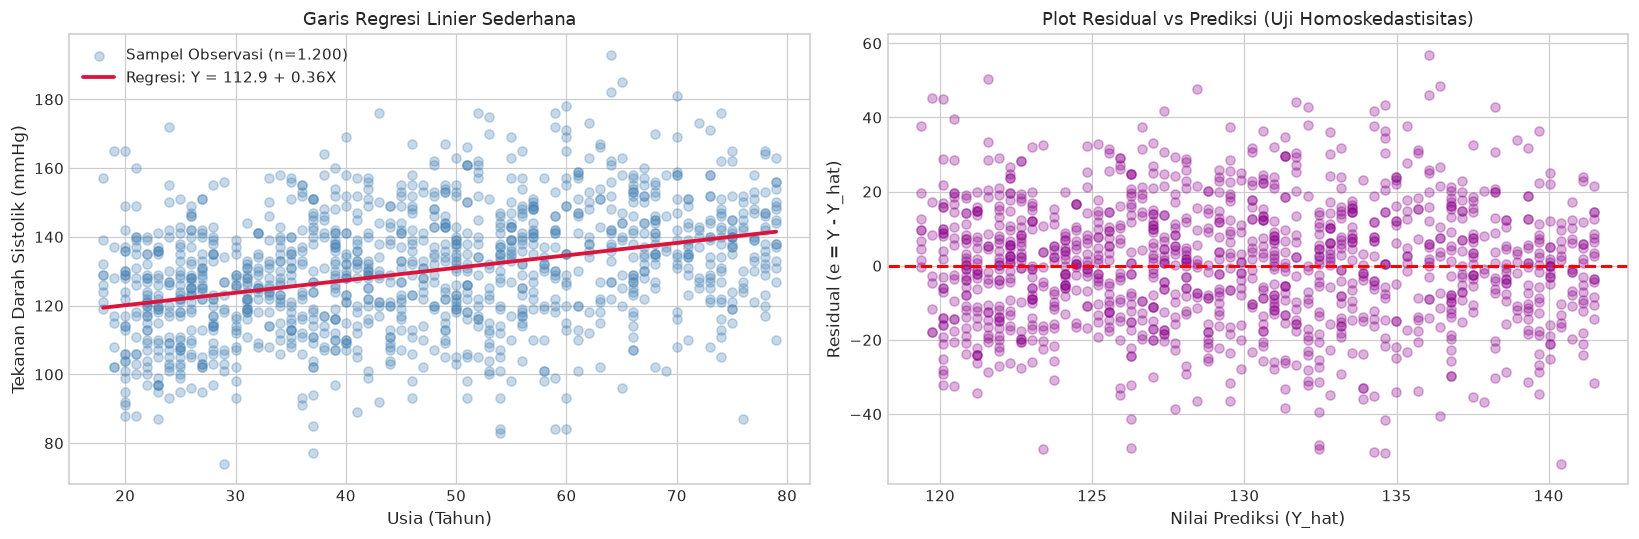

In [18]:
df_reg = df[['age', 'systolic_blood_pressure']].dropna()
x_reg = df_reg['age'].values
y_reg = df_reg['systolic_blood_pressure'].values

# Kovarians & Korelasi
cov_xy = np.cov(x_reg, y_reg)[0, 1]
r_p, p_corr = stats.pearsonr(x_reg, y_reg)
rho_s, p_spear = stats.spearmanr(x_reg, y_reg)

print("--- 1. Kovarians dan Korelasi ---")
print(f"Kovarians Sampel Cov(Usia, SBP) : {cov_xy:.4f}")
print(f"Korelasi Pearson (r)            : {r_p:.4f} (p-value: {p_corr:.4e})")
print(f"Korelasi Spearman (ρ)           : {rho_s:.4f} (p-value: {p_spear:.4e})")

# Regresi Linier Sederhana
X_mat = x_reg.reshape(-1, 1)
lin_model = LinearRegression()
lin_model.fit(X_mat, y_reg)

b1 = lin_model.coef_[0]
b0 = lin_model.intercept_
y_hat = lin_model.predict(X_mat)
r2_val = r2_score(y_reg, y_hat)
rmse_val = np.sqrt(mean_squared_error(y_reg, y_hat))

print("\n--- 2. Persamaan Garis Regresi Linier OLS ---")
print(f"Persamaan: SBP = {b0:.4f} + {b1:.4f} * Usia")
print(f"Intercept (β0) : {b0:.4f} mmHg")
print(f"Slope (β1)     : {b1:.4f} mmHg per tahun usia")
print(f"Koefisien Determinasi (R²) : {r2_val:.4f} ({r2_val*100:.2f}%)")
print(f"RMSE           : {rmse_val:.4f} mmHg")

# Visualisasi Regresi dan Residual
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sub_idx = np.random.choice(len(x_reg), size=1200, replace=False)
x_sub = x_reg[sub_idx]
y_sub = y_reg[sub_idx]
y_sub_pred = y_hat[sub_idx]
res_sub = y_sub - y_sub_pred

# Scatter & Garis Regresi
axes[0].scatter(x_sub, y_sub, alpha=0.3, color='steelblue', label='Sampel Observasi (n=1.200)')
x_line = np.linspace(x_reg.min(), x_reg.max(), 100).reshape(-1, 1)
axes[0].plot(x_line, lin_model.predict(x_line), color='crimson', lw=2.5, 
             label=f'Regresi: Y = {b0:.1f} + {b1:.2f}X')
axes[0].set_title("Garis Regresi Linier Sederhana")
axes[0].set_xlabel("Usia (Tahun)")
axes[0].set_ylabel("Tekanan Darah Sistolik (mmHg)")
axes[0].legend()

# Plot Residual
axes[1].scatter(y_sub_pred, res_sub, alpha=0.3, color='darkmagenta')
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title("Plot Residual vs Prediksi (Uji Homoskedastisitas)")
axes[1].set_xlabel("Nilai Prediksi (Y_hat)")
axes[1].set_ylabel("Residual (e = Y - Y_hat)")

plt.tight_layout()
plt.show()


---
## Modul 11: Ringkasan Eksekutif & Kesimpulan Akhir

Dari keseluruhan tahapan analisis statistika dan probabilitas semester 3 yang telah diterapkan, dirangkum poin-poin utama:

1. **Penyajian Data Berkelompok & Kurva Ogive:**
   - Aturan Sturges membagi variabel usia menjadi 18 kelas interval ($c=4$ tahun). Kurva Ogive mendemonstrasikan pola kumulatif pasien secara kontinu.
2. **Statistika Deskriptif:**
   - Variabel usia memiliki $\bar{x} = 46{,}94$ tahun, $Me = 47{,}00$ tahun, dan $CV = 36{,}14\%$. Tekanan darah sistolik memiliki $\bar{x} = 129{,}88$ mmHg dengan varians sampel $312{,}75$.
3. **Pemeriksaan Normalitas:**
   - Q-Q plot menunjukkan data empiris berada dekat dengan garis diagonal teoritis dengan deviasi ringan pada ekor distribusi.
4. **Teori Probabilitas & Bayes:**
   - Prevalensi serangan jantung adalah $6{,}64\%$. Pasien penderita diabetes memiliki peningkatan risiko serangan jantung sebesar $>30\%$ ($RR \approx 4{,}7\times$), dan teorema Bayes memvalidasi akurasi estimasi posterior empiris.
5. **Distribusi Probabilitas:**
   - Distribusi Binomial dan Poisson berhasil memodelkan variabel diskrit jumlah penderita dalam kelompok pengamatan $n=30$.
   - Distribusi Normal memperkirakan probabilitas pasien menderita hipertensi ($SBP \ge 140$ mmHg) sebesar $28{,}35\%$, bersesuaian dengan proporsi data aktual ($27{,}30\%$).
6. **Sampling & CLT:**
   - Teorema Limit Pusat terbukti secara empiris: seiring meningkatnya ukuran sampel dari $n=5$ ke $n=100$, distribusi rata-rata sampel semakin simetris dan galat baku mengecil sesuai formula $\frac{\sigma}{\sqrt{n}}$.
7. **Pengujian Hipotesis:**
   - **Two-Sample Welch $t$-Test & Mann-Whitney $U$ Test:** Menolak $H_0$ ($p < 0{,}001$), pasien serangan jantung signifikan memiliki usia lebih tua.
   - **Two-Sample $Z$-Test Proporsi:** Menolak $H_0$ ($p < 0{,}001$), proporsi serangan jantung pada laki-laki ($7{,}97\%$) signifikan lebih tinggi daripada perempuan ($5{,}29\%$).
   - **One-Way ANOVA:** Menolak $H_0$ ($p < 0{,}001$), rata-rata tekanan darah sistolik berbeda signifikan antarkategori usia.
   - **Chi-Square Goodness-of-Fit & Independence:** Menolak $H_0$, membuktikan deviasi gender dari proporsi 50:50 serta hubungan dependensi kuat antara komorbid diabetes dengan serangan jantung.
8. **Korelasi & Regresi:**
   - Terbukti terdapat korelasi positif antara Usia dan Tekanan Darah Sistolik ($r = 0{,}343$). Model regresi OLS membuktikan bahwa setiap penambahan 1 tahun usia berkontribusi terhadap kenaikan rata-rata tekanan darah sistolik sebesar $\approx 0{,}36$ mmHg.
